## Setup

In [37]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [38]:
from tapas_gmm.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm.policy.models.tpgmm
from tapas_gmm.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm.utils.logging import setup_logger  # noqa: F401
from tapas_gmm.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'CloseDoor'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [40]:
gt_pose_config = {
    #'indeces': [1,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [41]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([146, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([146]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([146, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([146, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([146, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([146, 3, 256, 256]), device=cpu, dt

In [42]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=10,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    use_bic=False, #Does prune segmentation
    drop_redundant_frames=True,
    gt_frames=[
        [0, 3],
        [0, 3],
    ]

)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.001,
    components_prop_to_len=True,
    min_end_distance=20,
    min_len=5
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [43]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 02:52:09.635 | INFO     |  Fitting AutoTPGMM
2025-08-16 02:52:09.635 | INFO     |  Segmenting trajectories


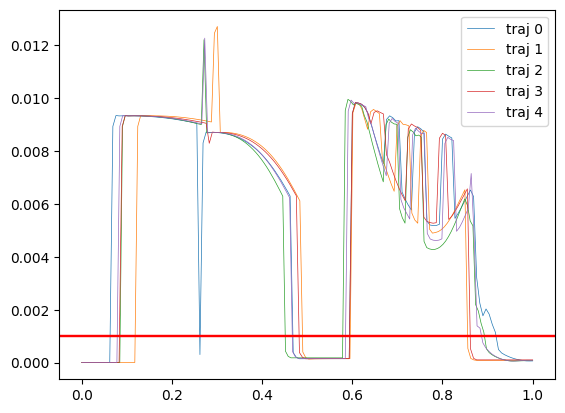

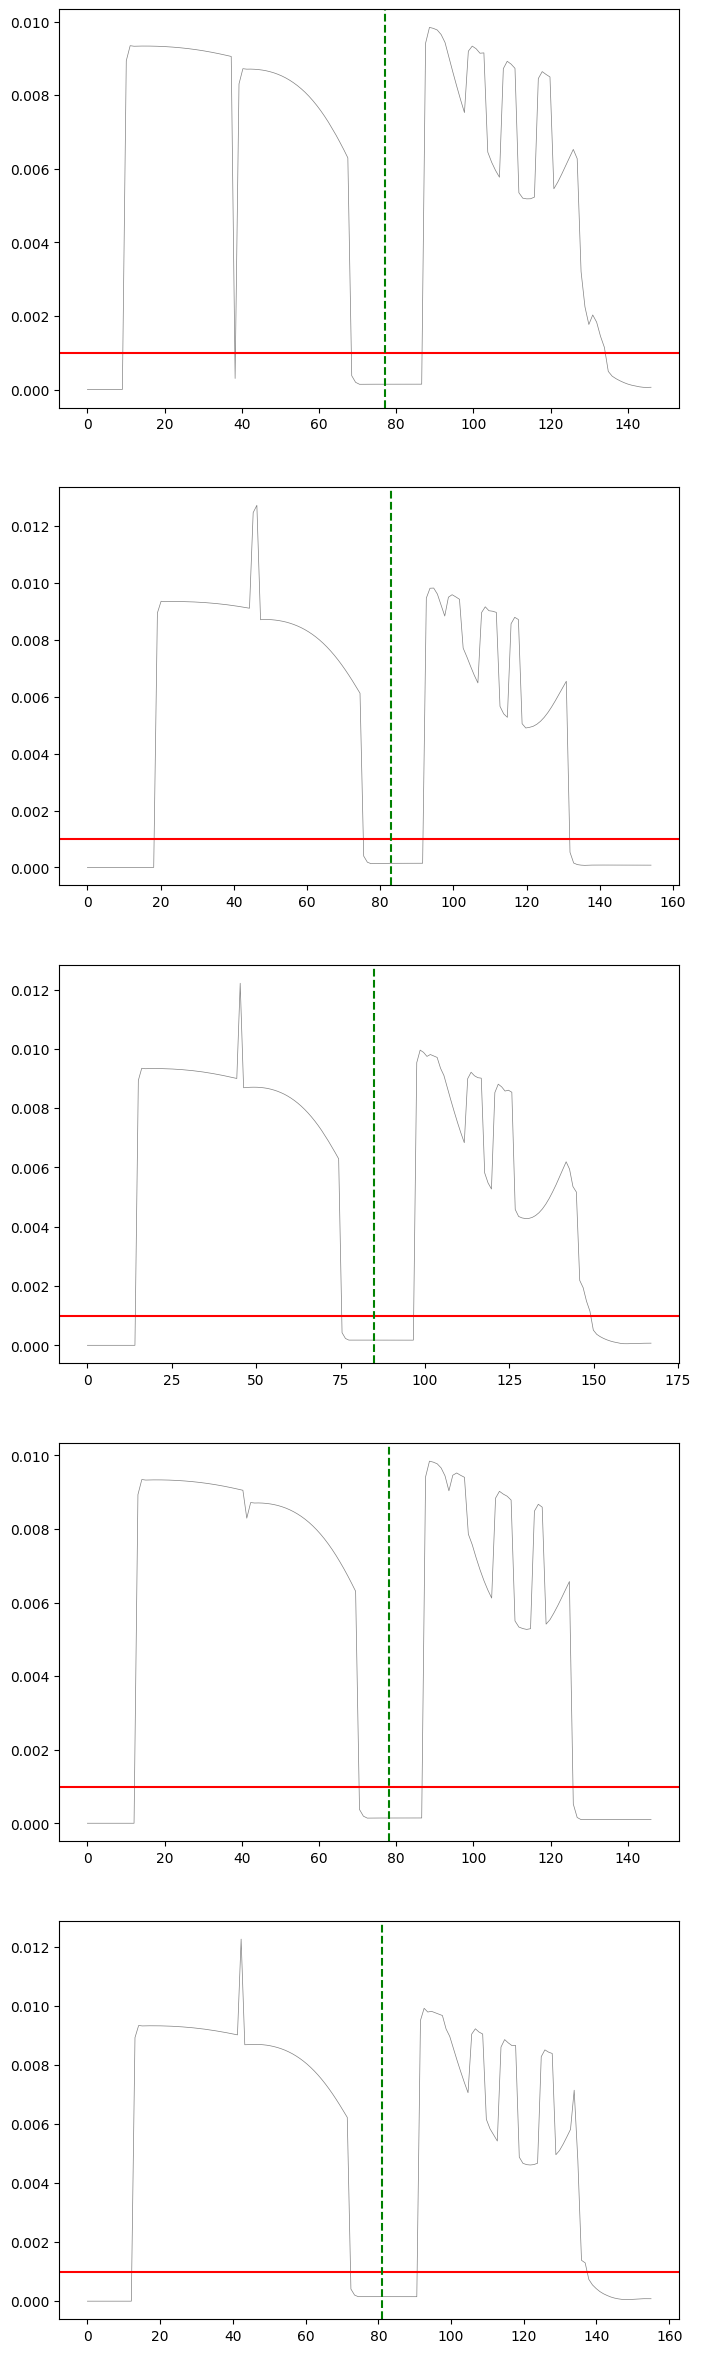

2025-08-16 02:52:09.870 | INFO     |  Creating segement of demos.
2025-08-16 02:52:09.872 | INFO     |  Creating segement of demos.
2025-08-16 02:52:09.874 | INFO     |  ... created 2 segments
2025-08-16 02:52:09.874 | INFO     |    Fitting candidate frame 1/10
2025-08-16 02:52:09.874 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-16 02:52:09.978 | INFO     |    Fitting candidate frame 2/10
2025-08-16 02:52:09.978 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-16 02:52:10.088 | INFO     |    Fitting candidate frame 3/10
2025-08-16 02:52:10.088 | INFO     |    Creating partial frame view of demos.


...

2025-08-16 02:52:12.021 | INFO     |  Creating partial frame view of demos.
2025-08-16 02:52:12.022 | INFO     |  Segmented trajs into 2 segments
2025-08-16 02:52:12.024 | INFO     |  Frame score (abs):
            ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0 -0.198282     -0.198282     -0.010787    -0.198305     -0.010502   
Segment 1 -0.197826     -0.197812     -0.003413    -0.197813     -0.025074   

           block_blue  block_pink  block_red       led  lightbulb  
Segment 0   -0.000050   -0.000011  -0.000197 -0.198282  -0.198282  
Segment 1   -0.000028   -0.000009  -0.000305 -0.197812  -0.197810  
2025-08-16 02:52:12.026 | INFO     |  Frame score (rel):
            ee_init  base__button  base__drawer  base__slide  base__switch  \
Segment 0  0.999886      0.999886      0.054396     1.000000      0.052960   
Segment 1  1.000000      0.999928      0.017251     0.999934      0.126748   

           block_blue  block_pink  block_red       led  lightbulb 

Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

((array([[7.29e+023, 7.29e+023, 4.45e+023, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [3.55e+020, 6.74e+020, 1.20e+021, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [3.10e-142, 1.60e-138, 6.75e-135, ..., 3.23e+013, 1.93e+012,
          9.47e+010],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 6.57e+022, 4.88e+022,
          3.33e+022]]),
  array([[2.02e+23, 2.00e+23, 1.22e+23, ..., 0.00e+00, 0.00e+00, 0.00e+00],
         [3.55e+19, 1.21e+20, 3.52e+20, ..., 1.10e-17, 7.35e-20, 4.19e-22],
         [5.21e-10, 3.68e-10, 2.51e-10, ..., 3.08e+18, 1.65e+18, 8.56e+17],
         [0.00e+00, 0.00e+00, 0.00e+00, ..., 6.47e+21, 4.80e+21, 3.23e+21]])),
 (-50.656231632020315, -49.80369637109356))

In [44]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 02:52:12.509 | INFO     |  Did not specify time_based, deciding automatically.


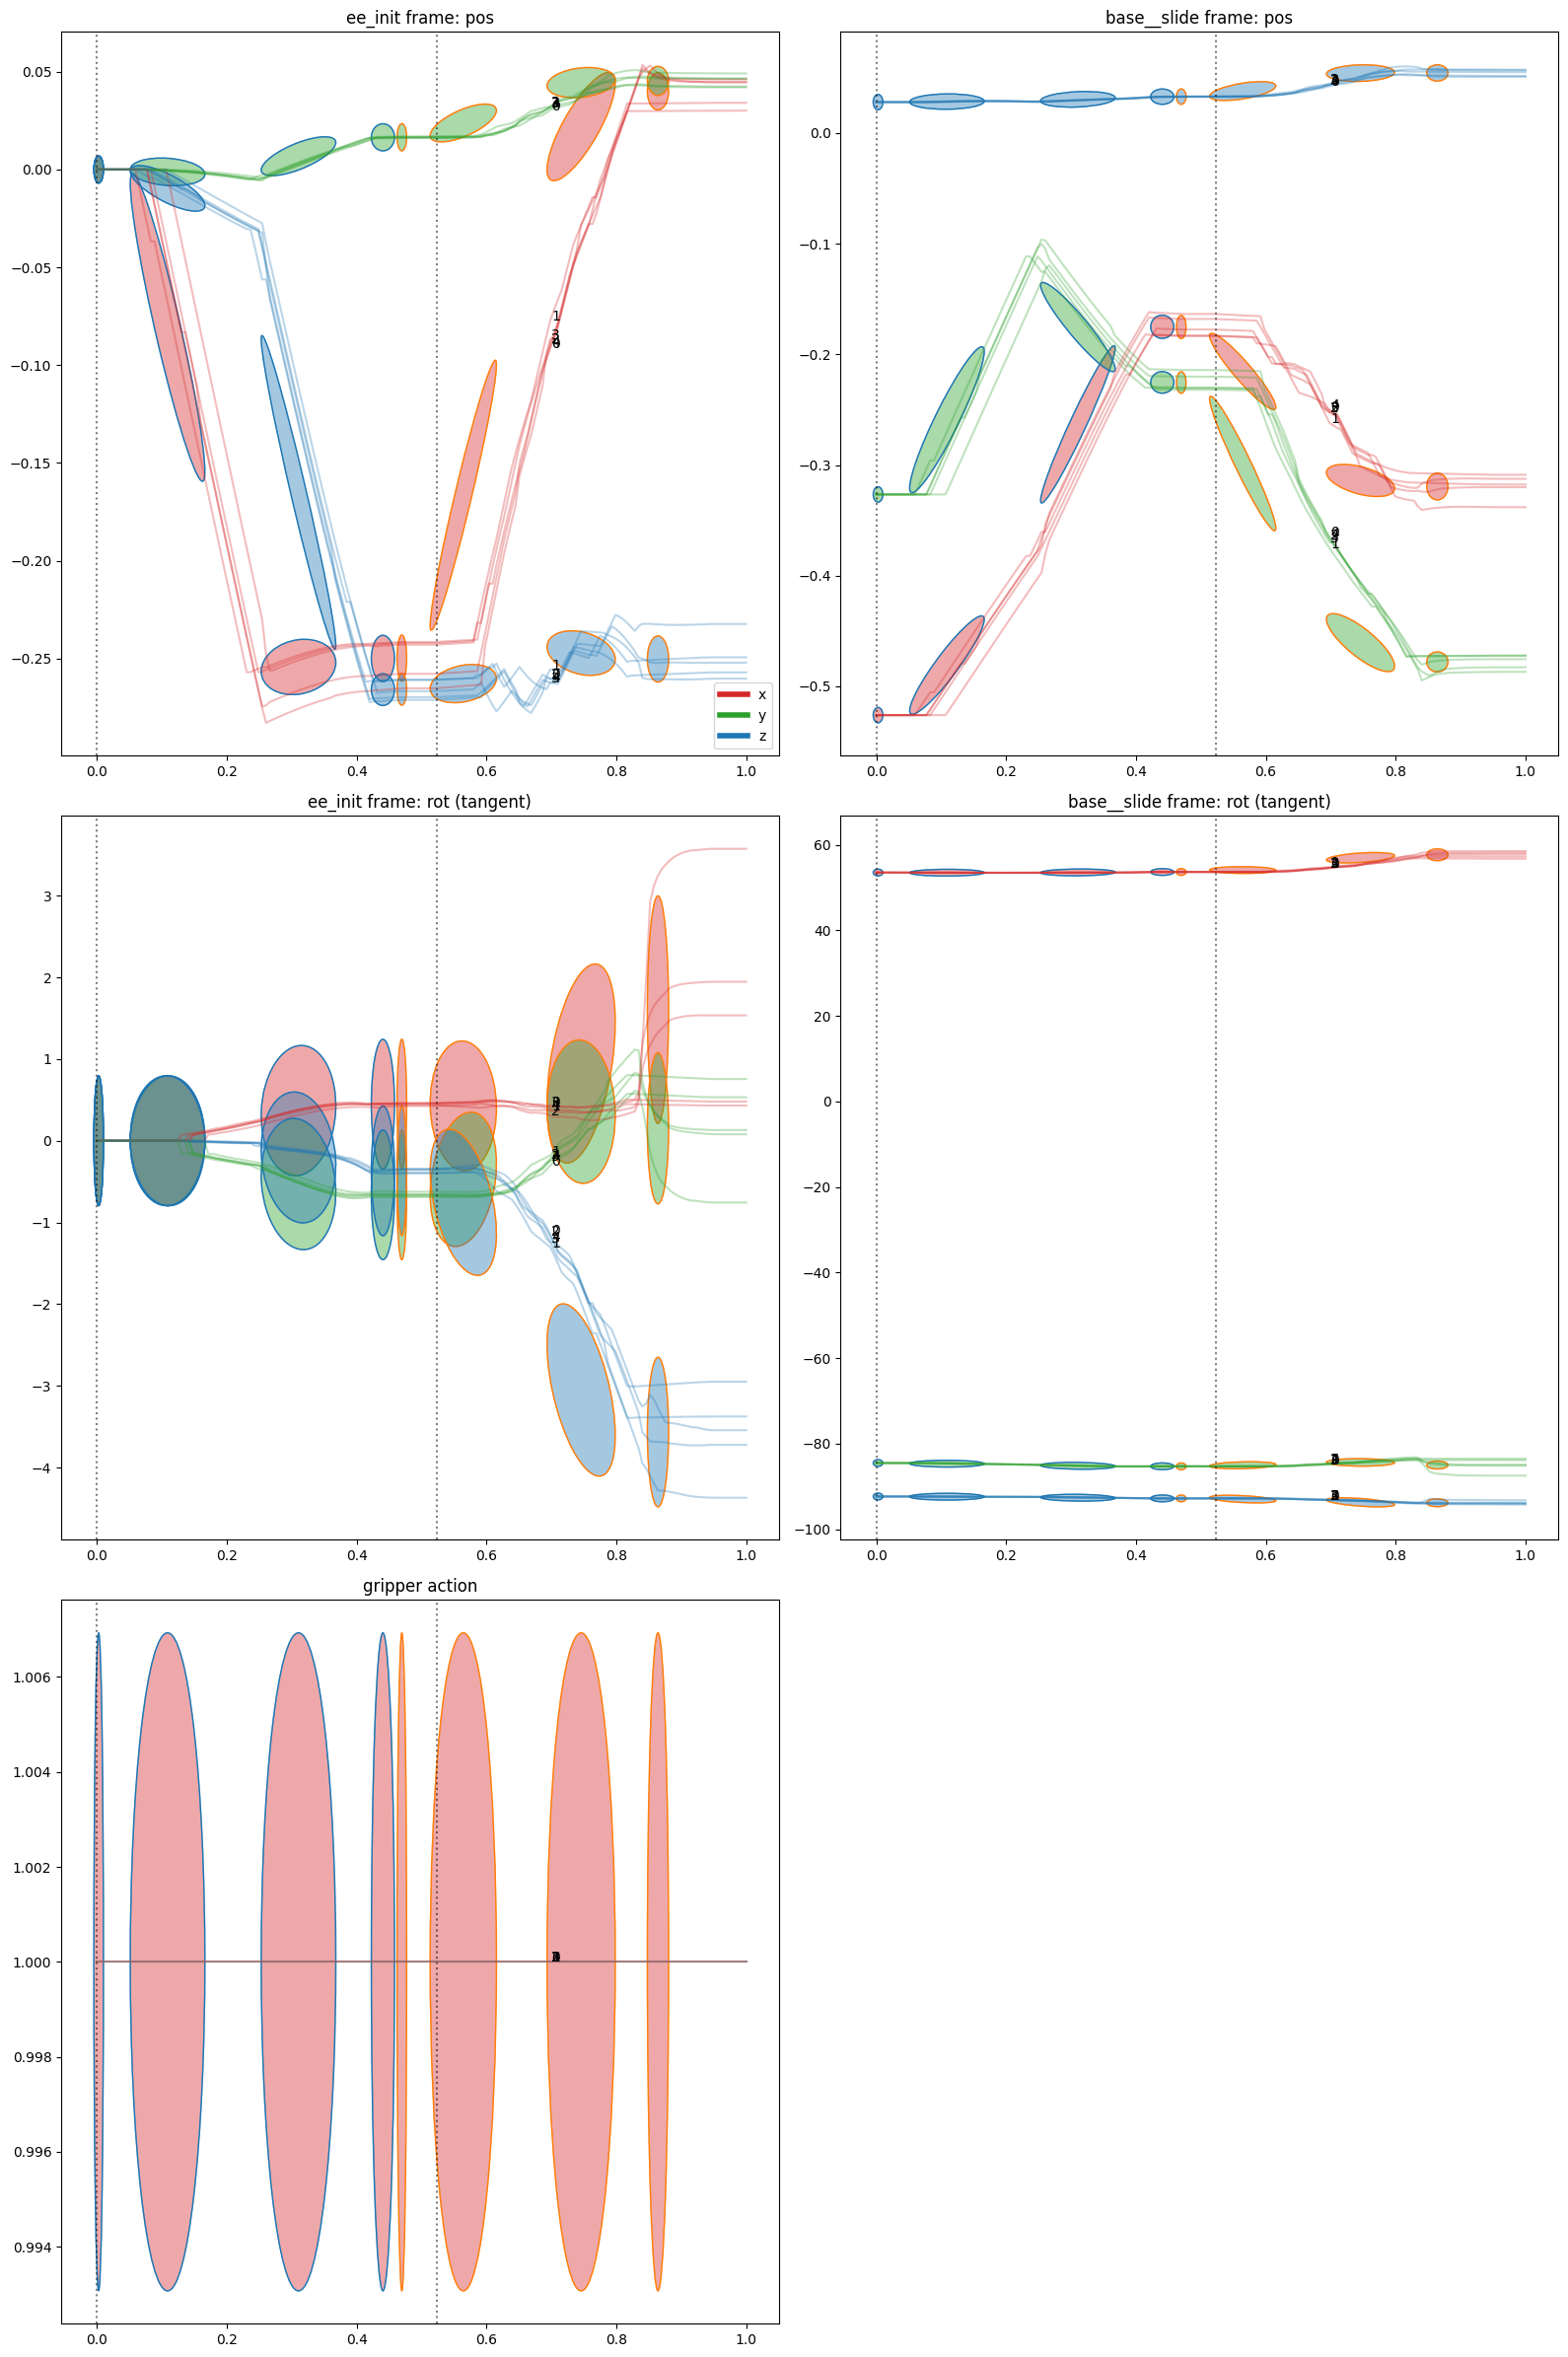

In [45]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [46]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 02:52:13.213 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [6.23e-209, 1.59e-045, 1.00e-036, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 4.83e-127, 2.59e-139,
          6.92e-151],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 1.00e+000, 1.00e+000,
          1.00e+000]]),
  array([[1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 9.06e-039, 8.31e-031, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 4.12e-127, 7.76e-140,
          9.65e-152],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 1.00e+000, 1.00e+000,
          1.00e+000]])),
 (3951.7730079734524, 3584.412190016951))

2025-08-16 02:52:22.340 | INFO     |  Did not specify time_based, deciding automatically.


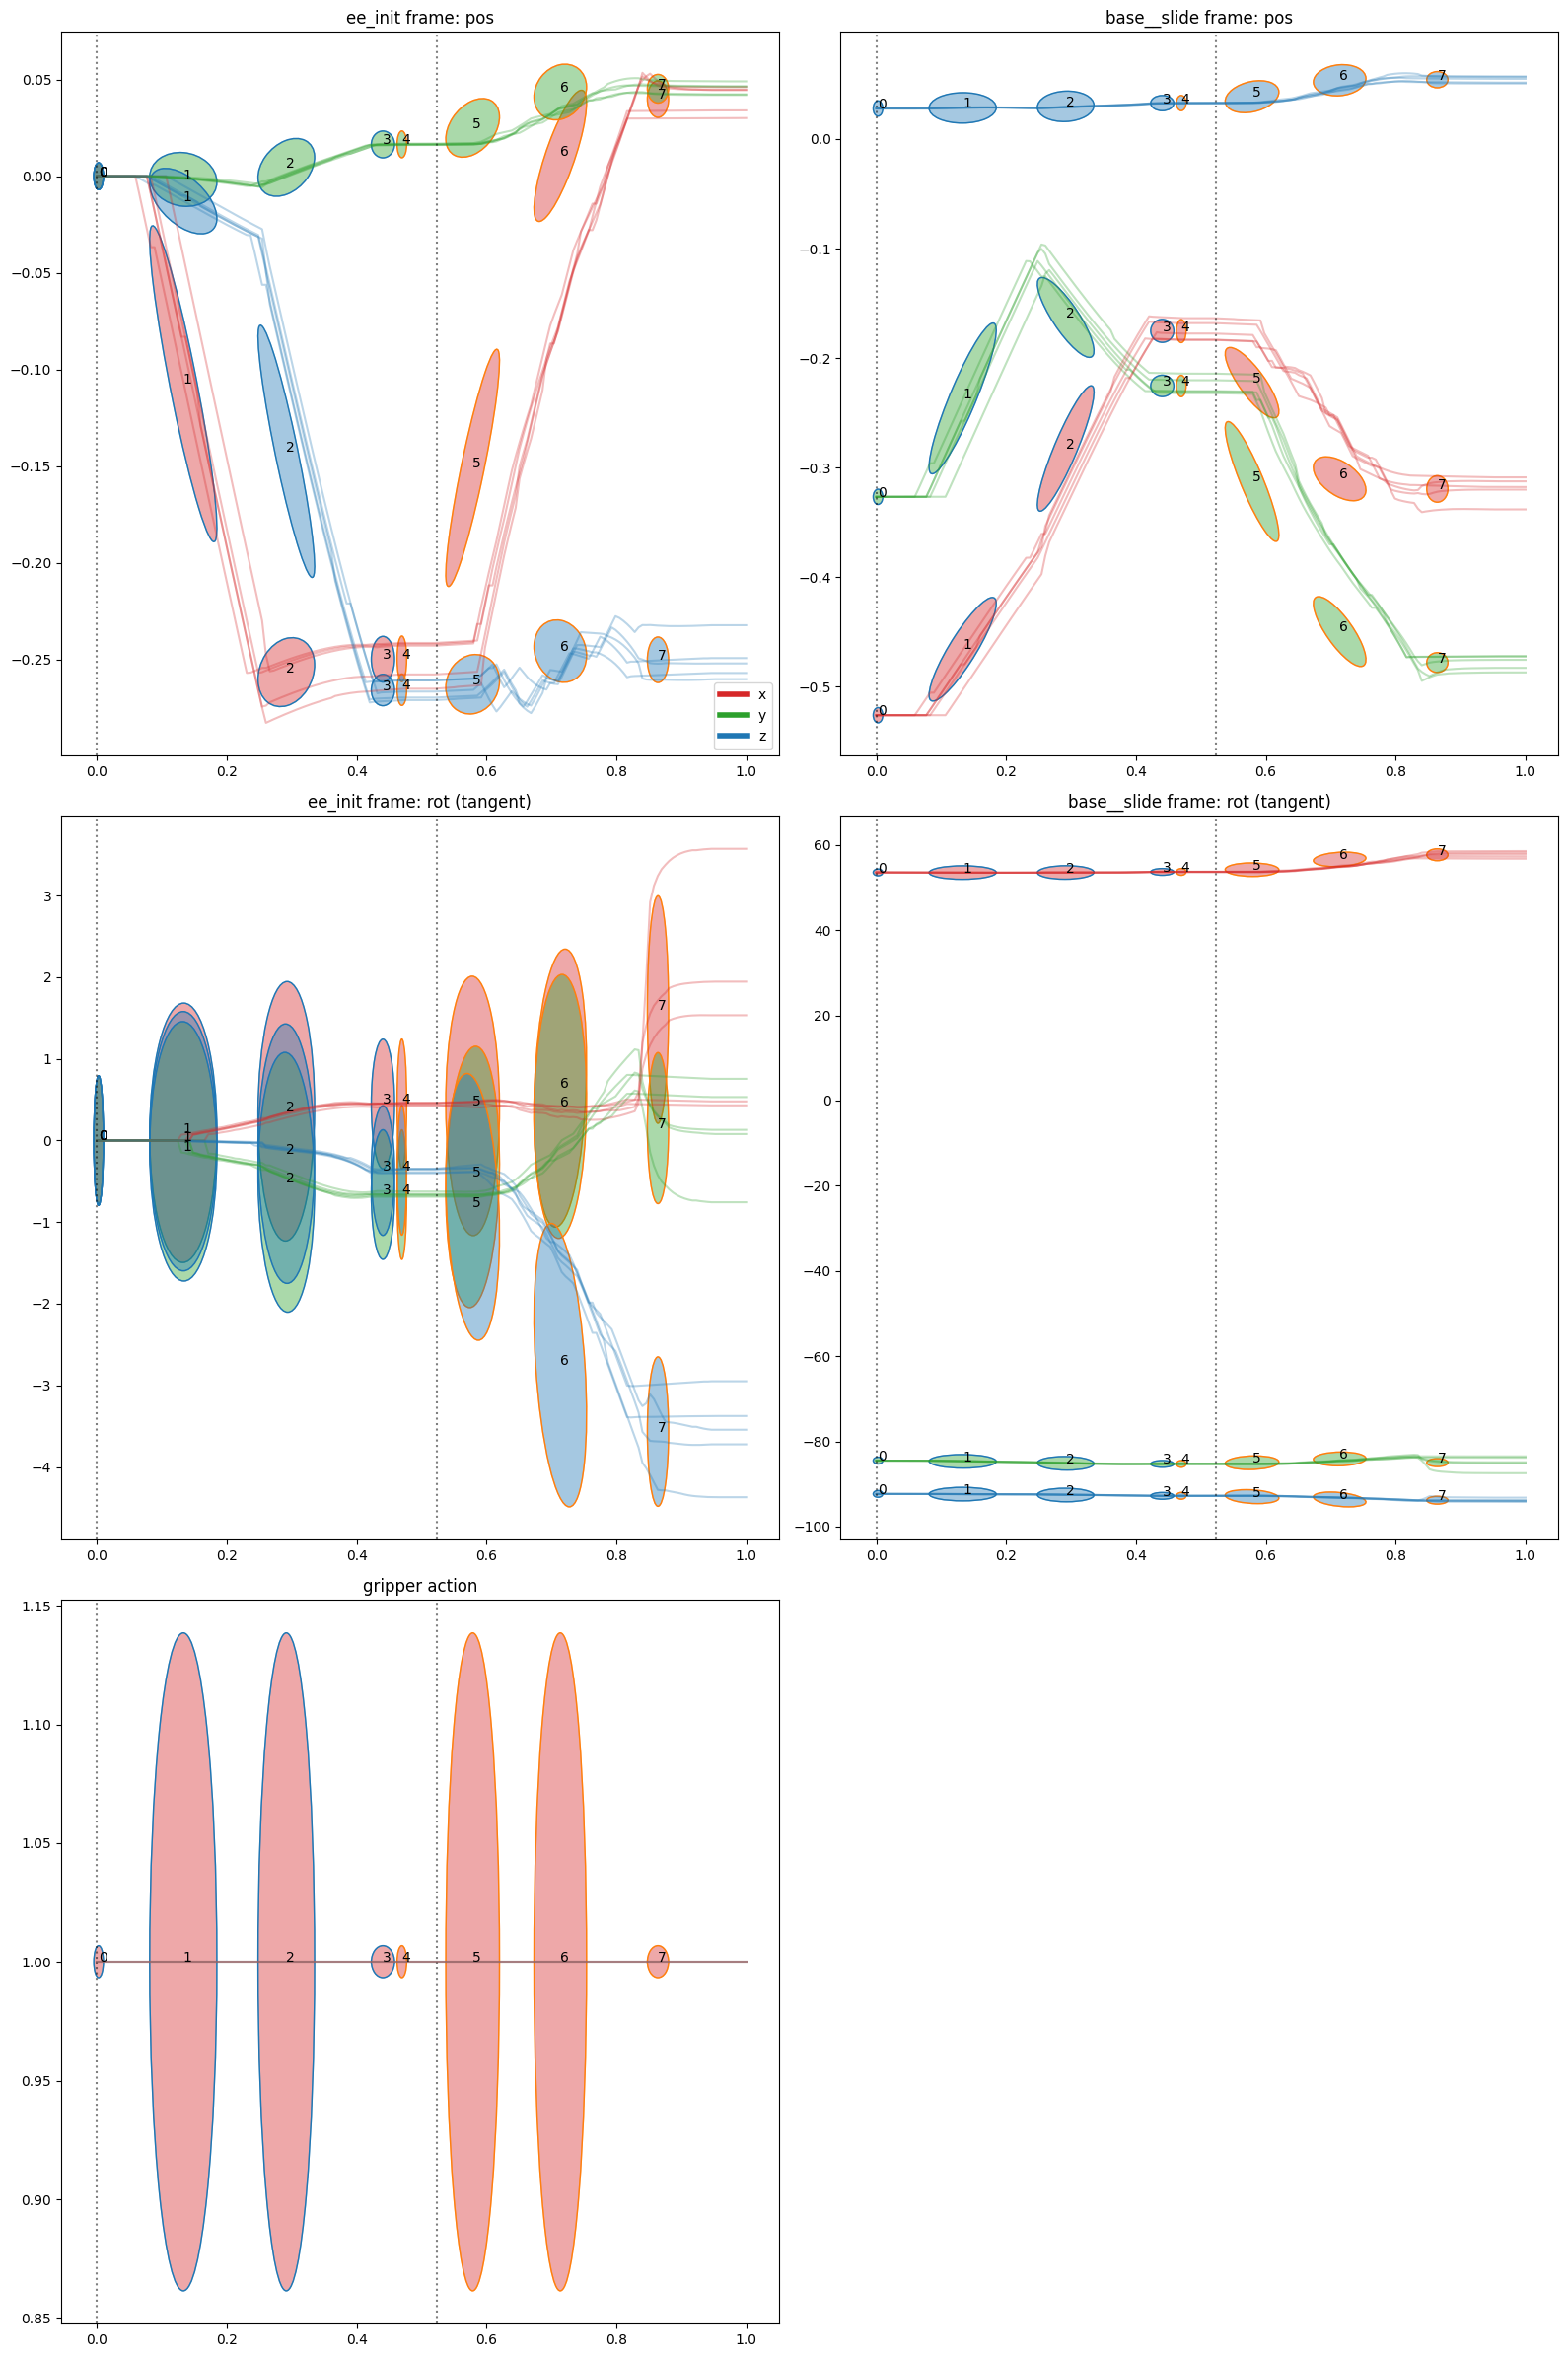

In [47]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

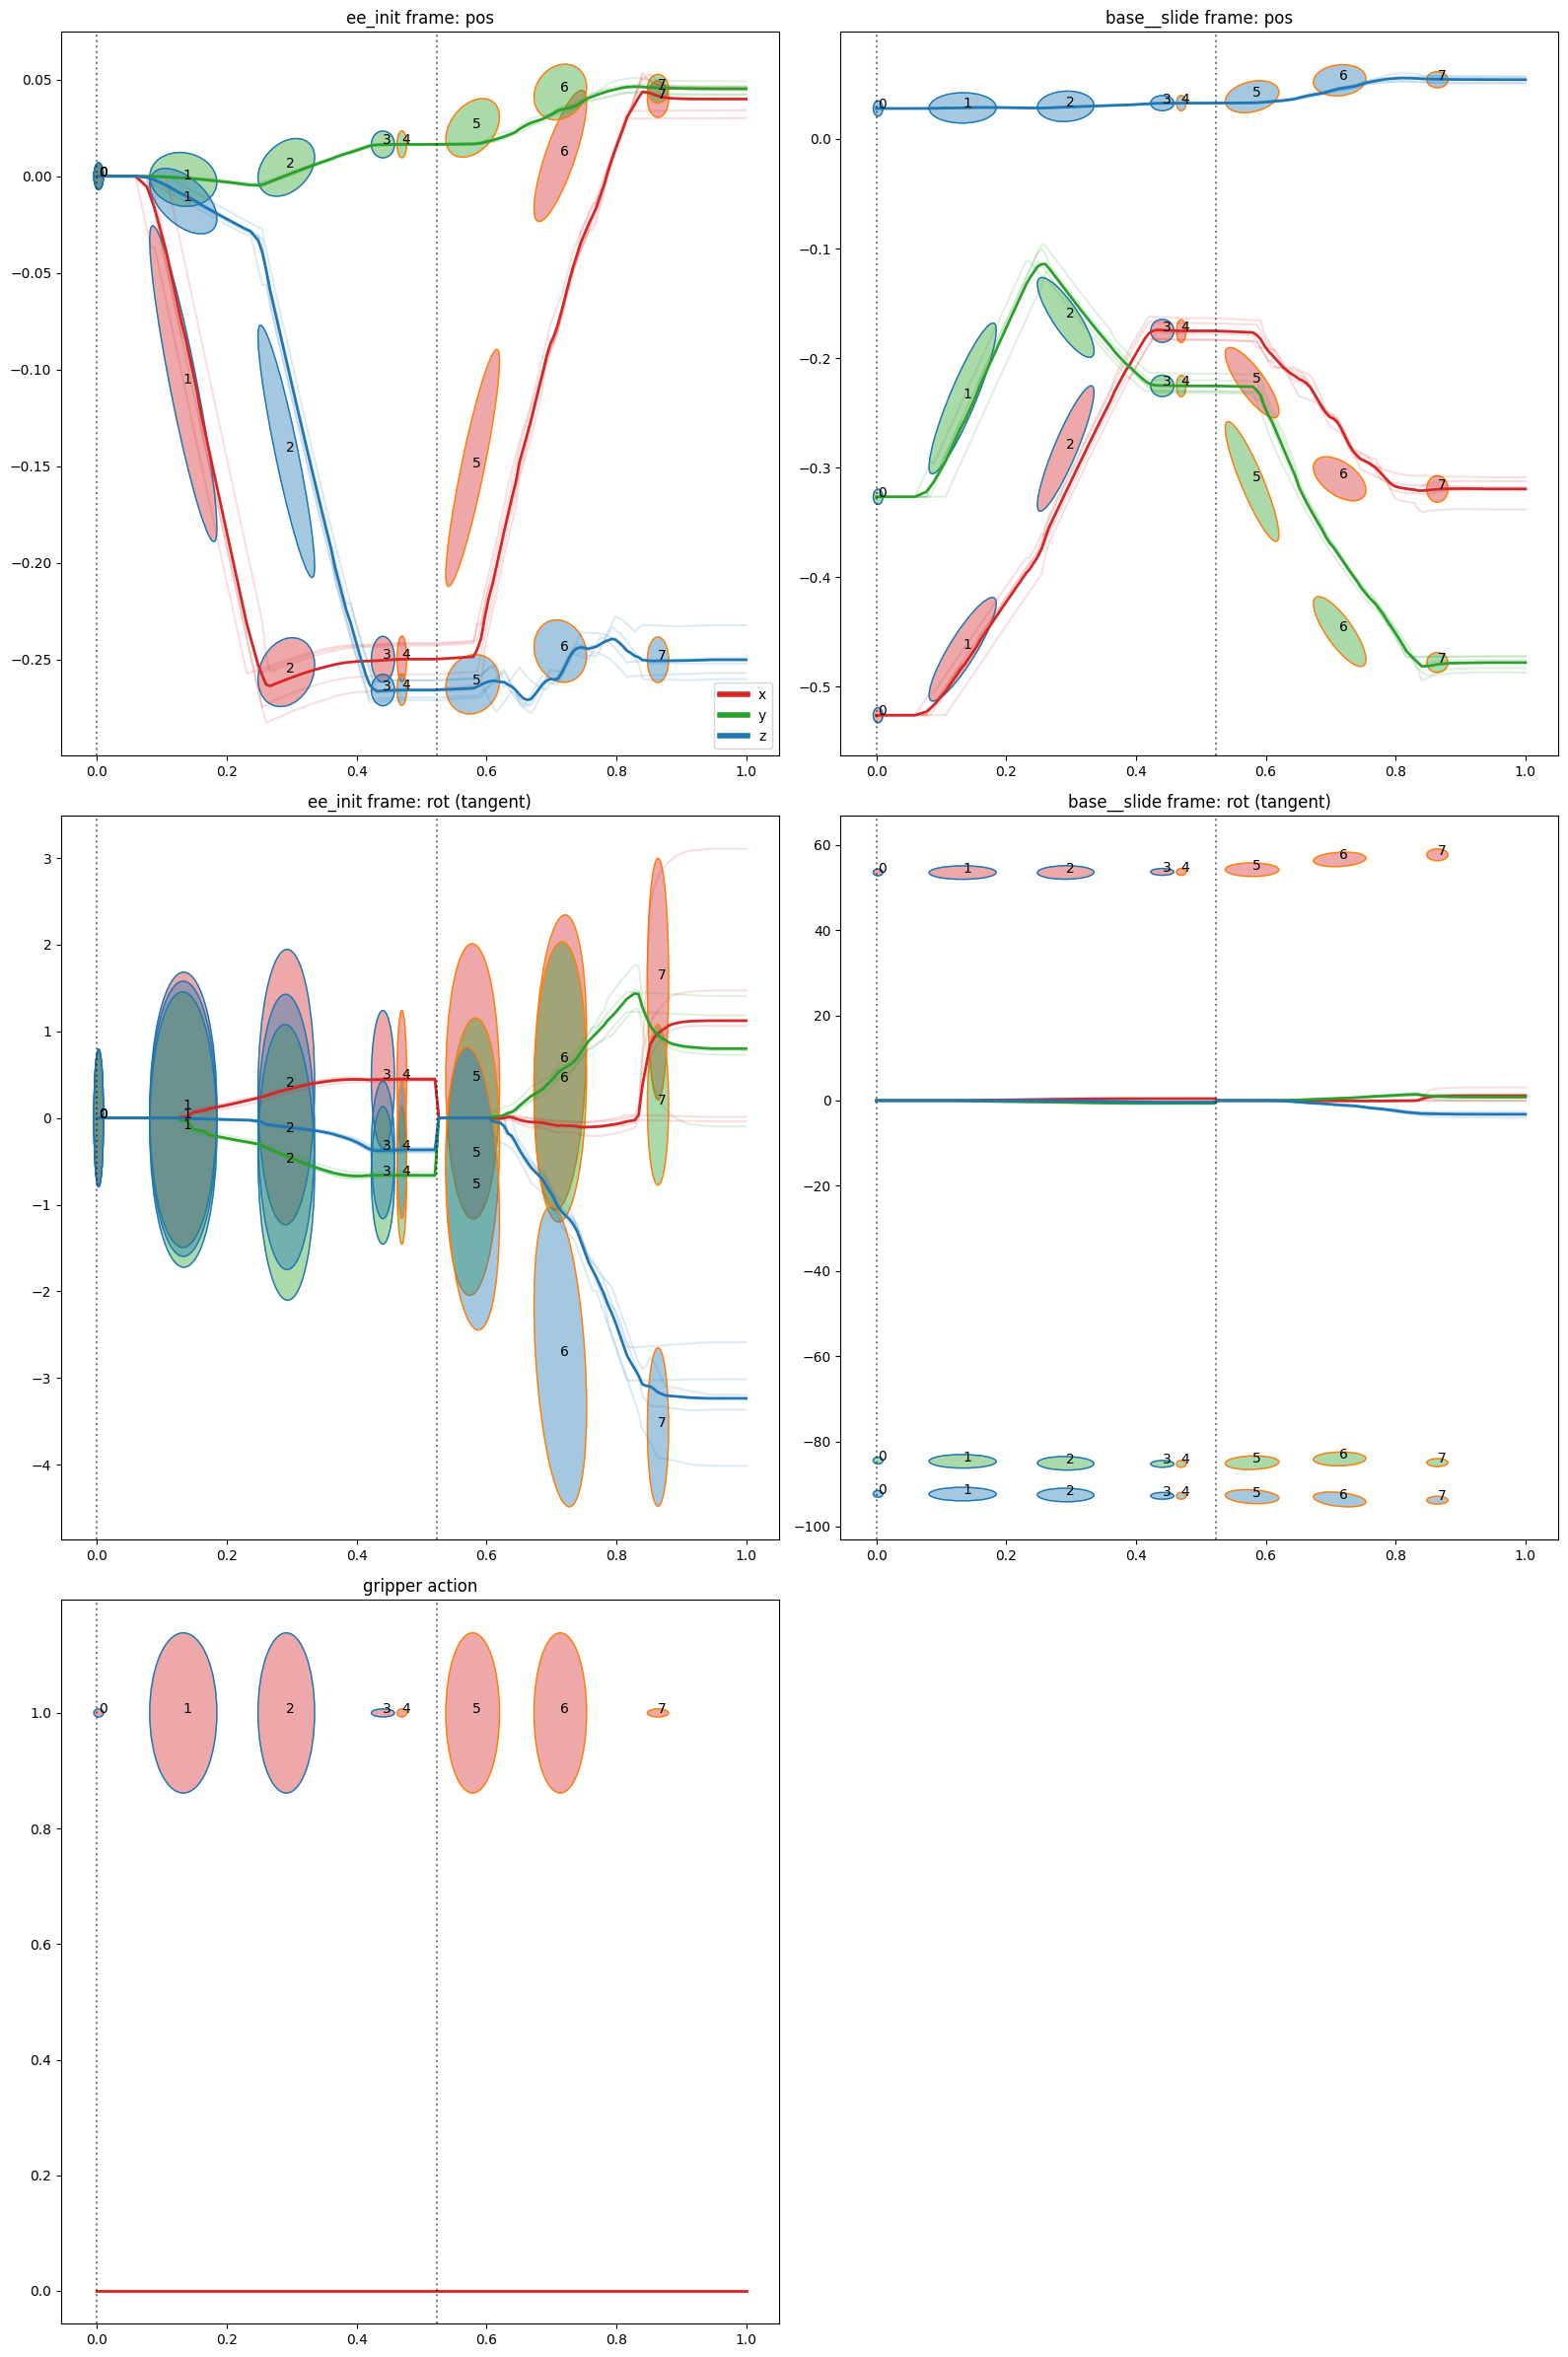

In [48]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

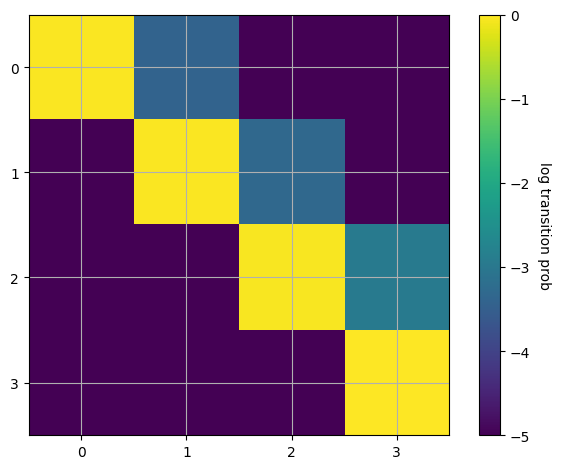

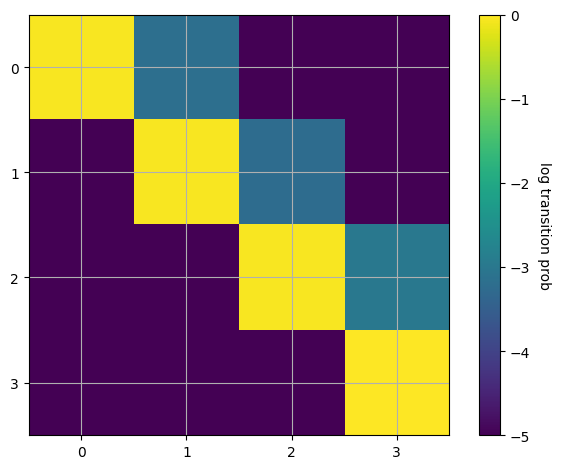

In [49]:
atpgmm.plot_hmm_transition_matrix()

In [50]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

In [51]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 02:52:33.117 | INFO     |  Caculated segment transition probabilities: (array([[0.]]),)
2025-08-16 02:52:33.117 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 02:52:33.168 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

GMR:   0%|          | 0/5 [00:00<?, ?it/s]

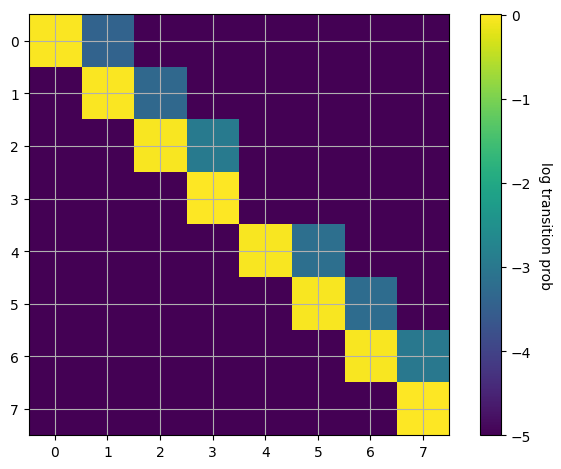

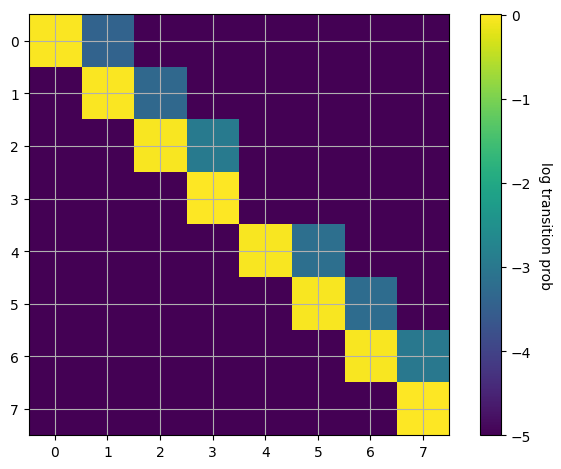

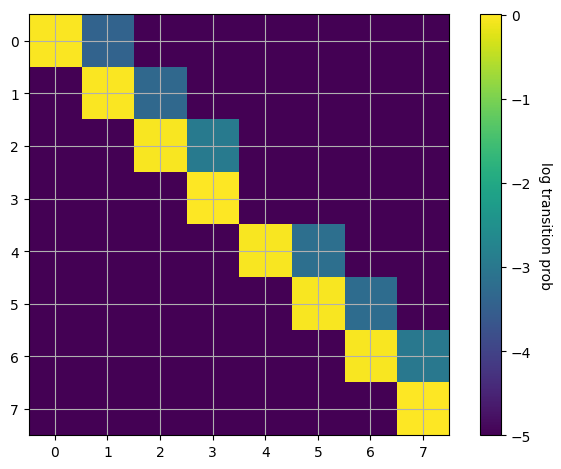

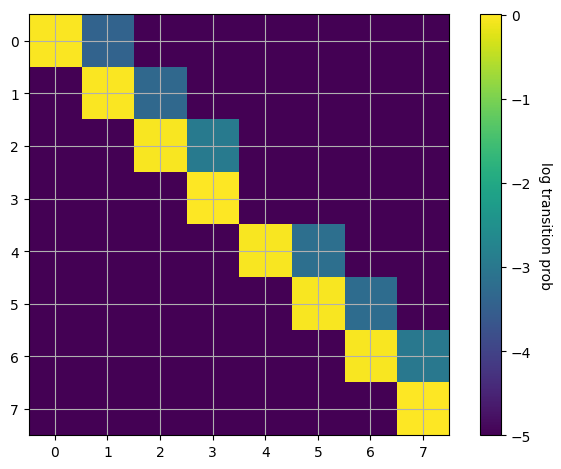

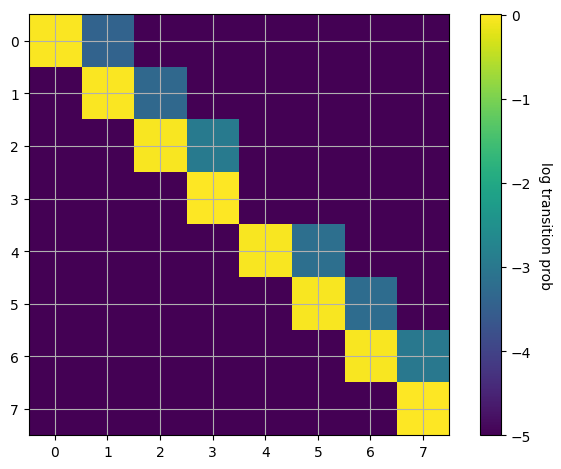

In [52]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 02:52:35.151 | INFO     |  Taking frame origins from demos.


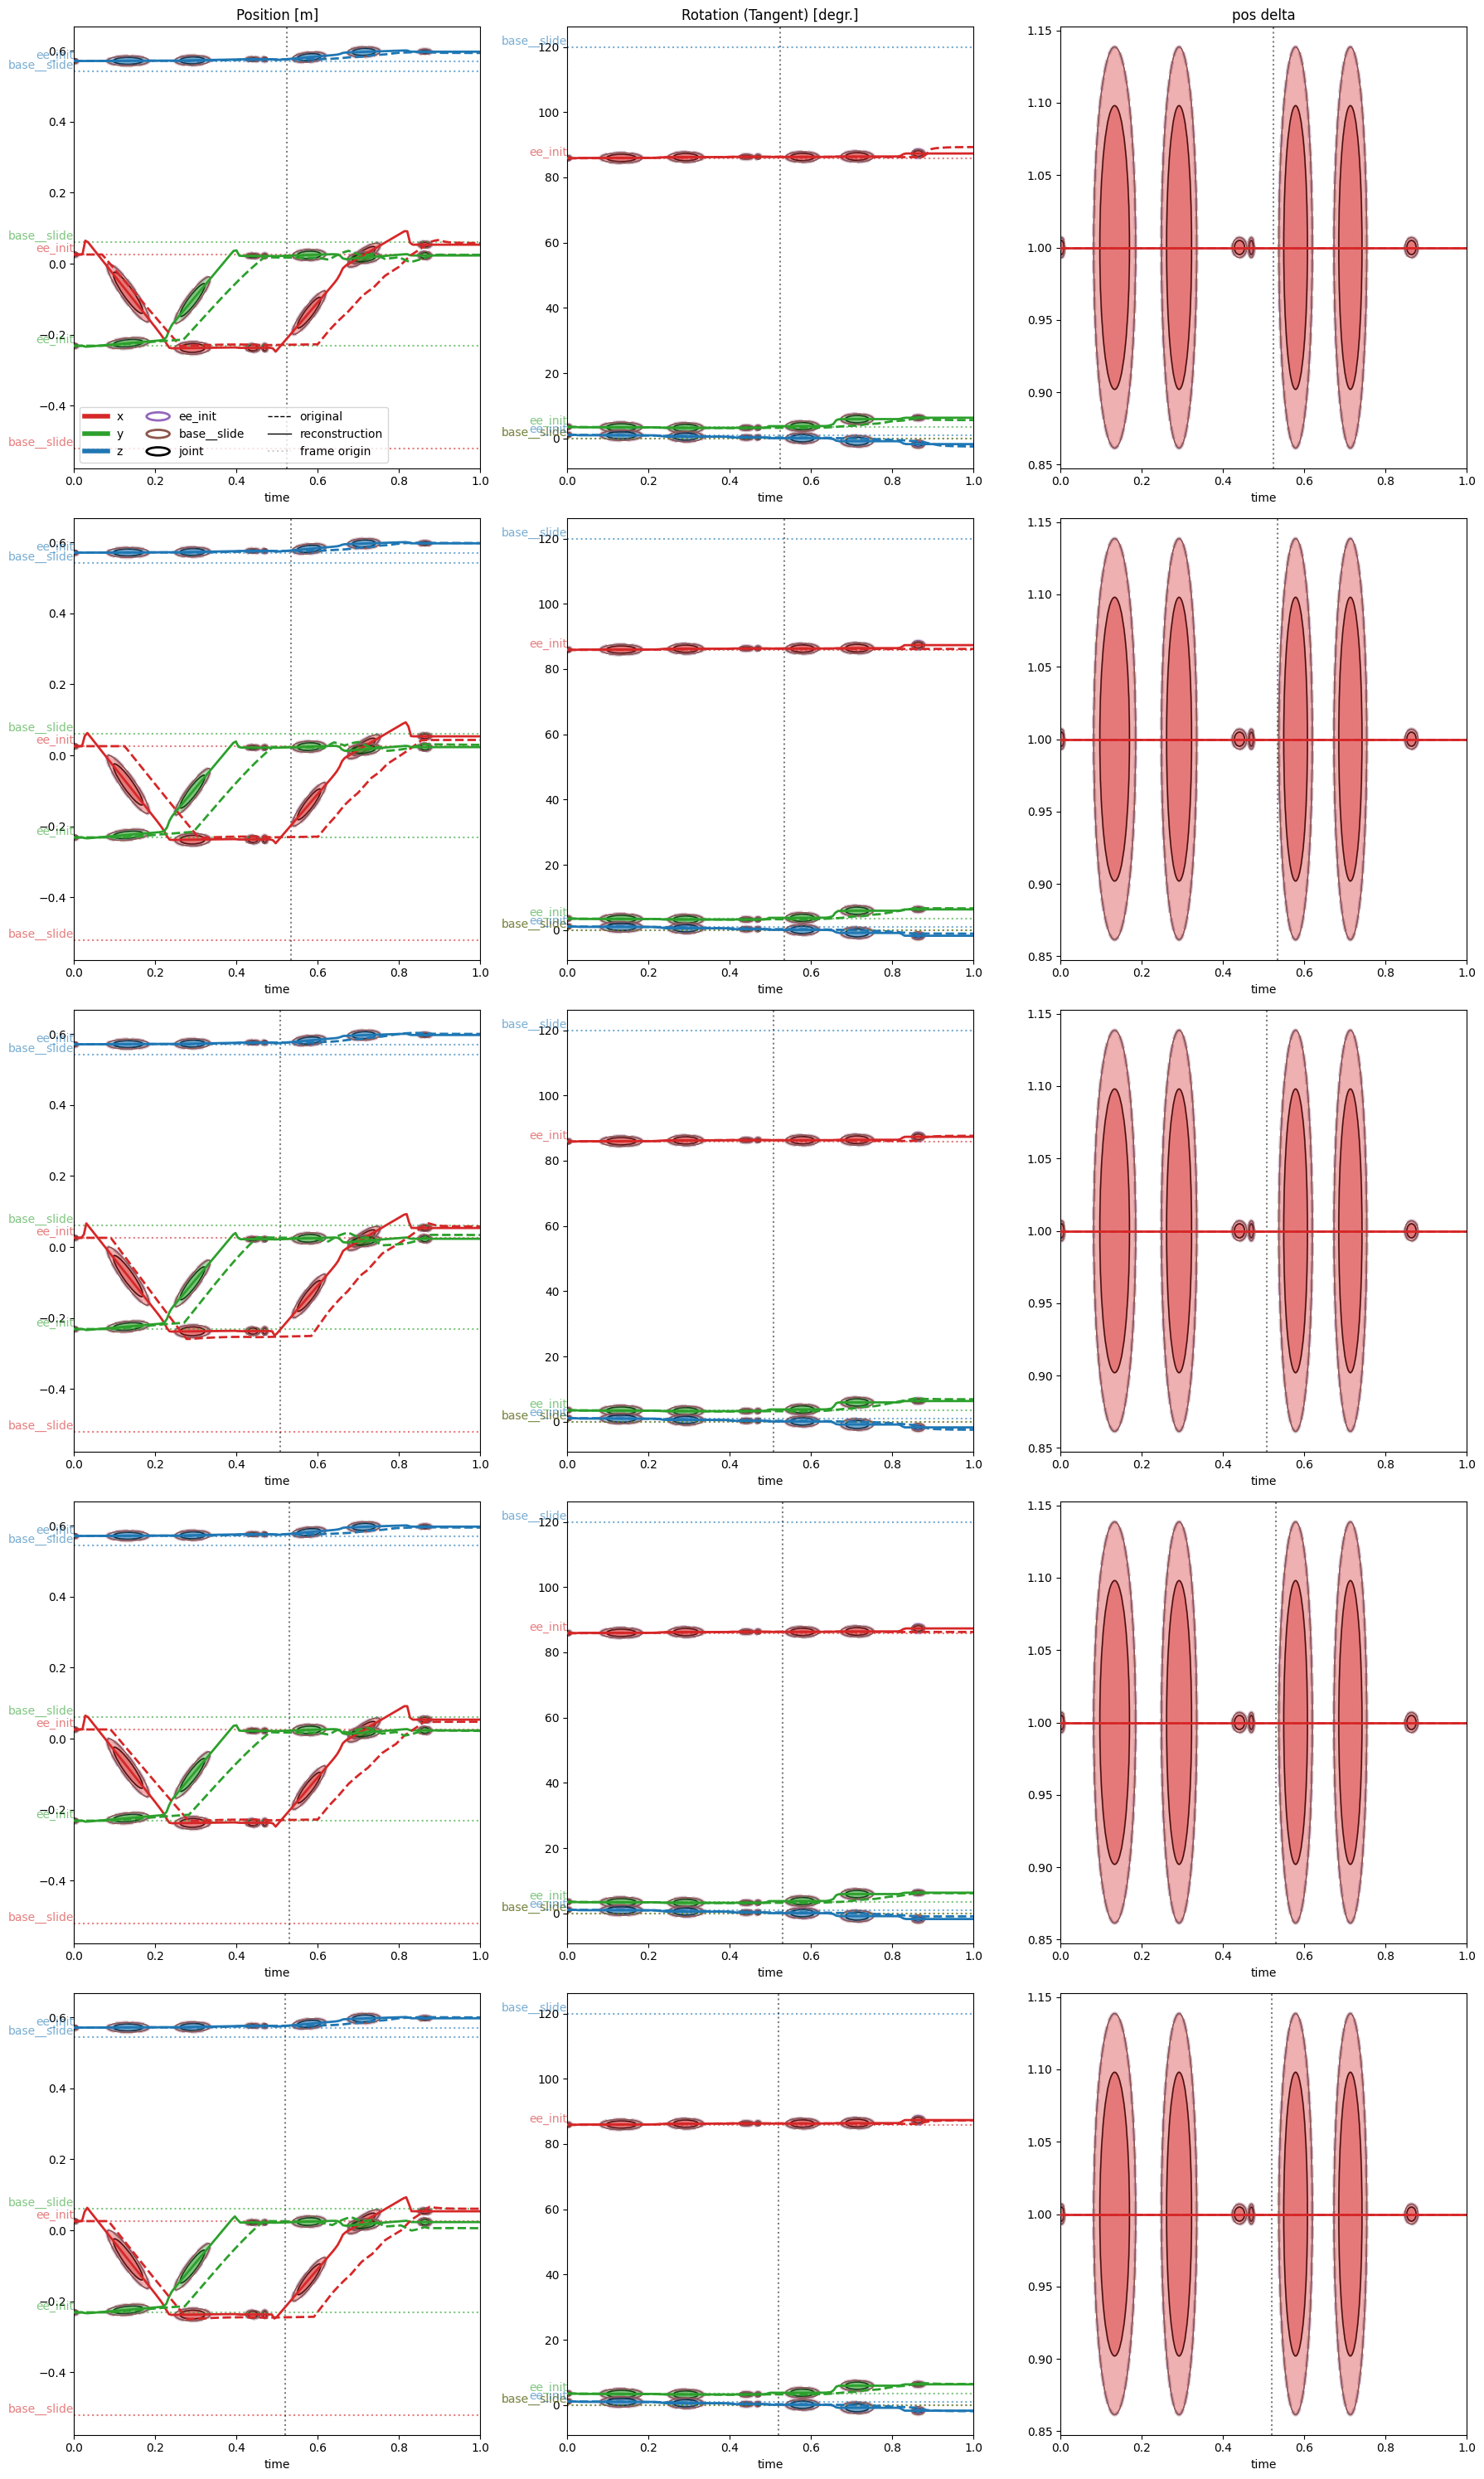

In [53]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [54]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range